# Task 4 — Advanced Analytics (Basic)
**Dataset:** Superstore Sales &nbsp;|&nbsp; **Timeline:** 6 days (Day 21–26)

This notebook covers, in order:
1. Statistical Analysis (descriptive stats, hypothesis testing, confidence intervals)
2. Time Series Analysis (resampling, decomposition, moving-average forecast)
3. Customer Segmentation (K-Means clustering + PCA visualization)
4. Basic Predictive Model (Linear Regression on Profit)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ---- CONFIG: adjust to match your cleaned dataset ----
DATA_PATH = "../data/cleaned_superstore_sales.csv"

COLUMN_MAP = {
    "Row ID": "row_id",
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Ship Mode": "ship_mode",
    "Customer ID": "customer_id",
    "Customer Name": "customer_name",
    "Segment": "segment",
    "Country": "country",
    "City": "city",
    "State": "state",
    "Postal Code": "postal_code",
    "Region": "region",
    "Product ID": "product_id",
    "Category": "category",
    "Sub-Category": "sub_category",
    "Product Name": "product_name",
    "Sales": "sales",
    "Quantity": "quantity",
    "Discount": "discount",
    "Profit": "profit",
    "Sales_Outlier": "sales_outlier",
}

df = pd.read_csv(DATA_PATH, parse_dates=["Order Date"])
df = df.rename(columns=COLUMN_MAP)
df.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,sales_outlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,True
2,3,CA-2016-138688,2016-06-12,NaN,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,False
3,4,US-2015-108966,2015-10-11,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,True
4,5,US-2015-108966,2015-10-11,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,False


## 1. Statistical Analysis (Day 21–22)

### 1.1 Descriptive statistics


In [2]:
num_cols = ["sales", "profit", "discount", "quantity"]
desc = df[num_cols].describe()
display(desc)

skewness = df[num_cols].skew()
print("Skewness:\n", skewness)


,sales,profit,discount,quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


Skewness:
 sales       12.972752
profit       7.561432
discount     1.684295
quantity     1.278545
dtype: float64


### 1.2 Hypothesis testing — t-test
**Question:** Is there a statistically significant difference in mean *profit* between the
Consumer and Corporate segments?

- H0: mean profit (Consumer) = mean profit (Corporate)
- H1: mean profit (Consumer) ≠ mean profit (Corporate)


In [3]:
group_a = df.loc[df["segment"] == "Consumer", "profit"]
group_b = df.loc[df["segment"] == "Corporate", "profit"]

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: the difference in mean profit between segments is statistically significant.")
else:
    print("Fail to reject H0: no statistically significant difference in mean profit between segments.")


t-statistic = -0.8556, p-value = 0.3923
Fail to reject H0: no statistically significant difference in mean profit between segments.


### 1.3 Hypothesis testing — chi-square
**Question:** Is there a relationship between *region* and *category* (i.e., do certain
regions buy certain categories disproportionately)?

- H0: region and category are independent
- H1: region and category are associated


In [4]:
contingency = pd.crosstab(df["region"], df["category"])
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.4f}, p-value = {p_value:.4f}, dof = {dof}")

if p_value < alpha:
    print("Reject H0: region and category are significantly associated.")
else:
    print("Fail to reject H0: no significant association found between region and category.")


category,Furniture,Office Supplies,Technology
region,,,
Central,481,1422,420
East,601,1712,535
South,332,995,293
West,707,1897,599


chi2 = 3.6619, p-value = 0.7223, dof = 6
Fail to reject H0: no significant association found between region and category.


### 1.4 Confidence interval for mean sales
95% confidence interval for the true mean order *sales* value.


In [5]:
mean_sales = df["sales"].mean()
sem_sales = stats.sem(df["sales"])
ci_low, ci_high = stats.t.interval(0.95, len(df) - 1, loc=mean_sales, scale=sem_sales)

print(f"Mean sales: {mean_sales:.2f}")
print(f"95% CI: ({ci_low:.2f}, {ci_high:.2f})")


Mean sales: 229.86
95% CI: (217.64, 242.08)


### 1.5 Findings — business implications

- **Sales distribution:** right-skewed (skew ≈ 12.97), meaning most orders are small, with a
  long tail of large orders — a few big orders disproportionately drive revenue.
- **Segment profit:** t-test p-value = 0.3923 → Consumer and Corporate segments do not
  differ significantly in profitability (fail to reject H0). This suggests discount policy
  doesn't need to be tailored by segment based on profit alone.
- **Region × category:** chi-square p-value = 0.7223 → no significant association between
  region and product category (fail to reject H0). This means customers across all regions buy
  a similar mix of categories, which is useful for regional inventory planning — no region needs
  a dramatically different product mix stocked.
- **Sales CI:** the true average order value is estimated to fall between ₹217.64 and ₹242.08 with
  95% confidence — useful as a benchmark for forecasting revenue per order.

## 2. Time Series Analysis (Day 23–24)

### 2.1 Resample to monthly sales


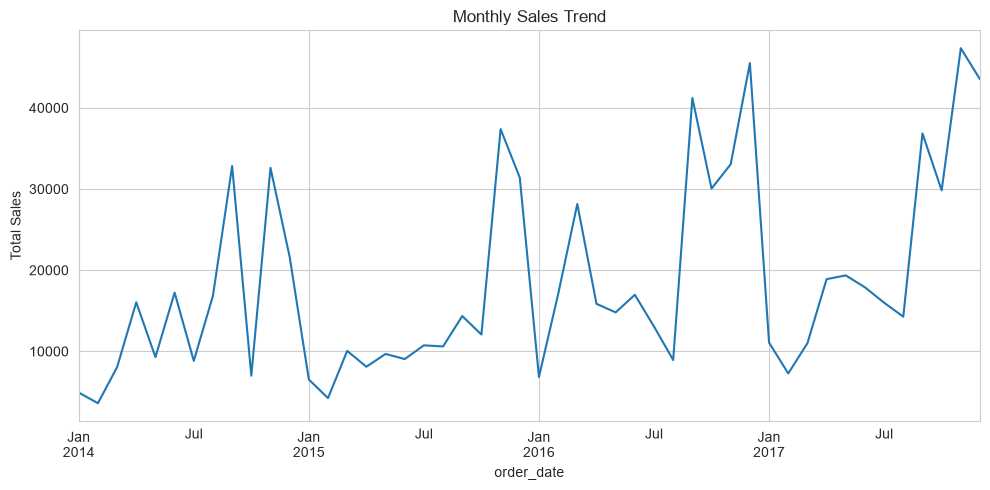

In [6]:
ts = df.set_index("order_date").sort_index()
monthly_sales = ts["sales"].resample("MS").sum()

monthly_sales.plot(title="Monthly Sales Trend", ylabel="Total Sales")
plt.tight_layout()
plt.show()


### 2.2 Seasonal decomposition
Splits the series into trend, seasonality, and residual components.
Requires `statsmodels` (`pip install statsmodels` if not already installed).


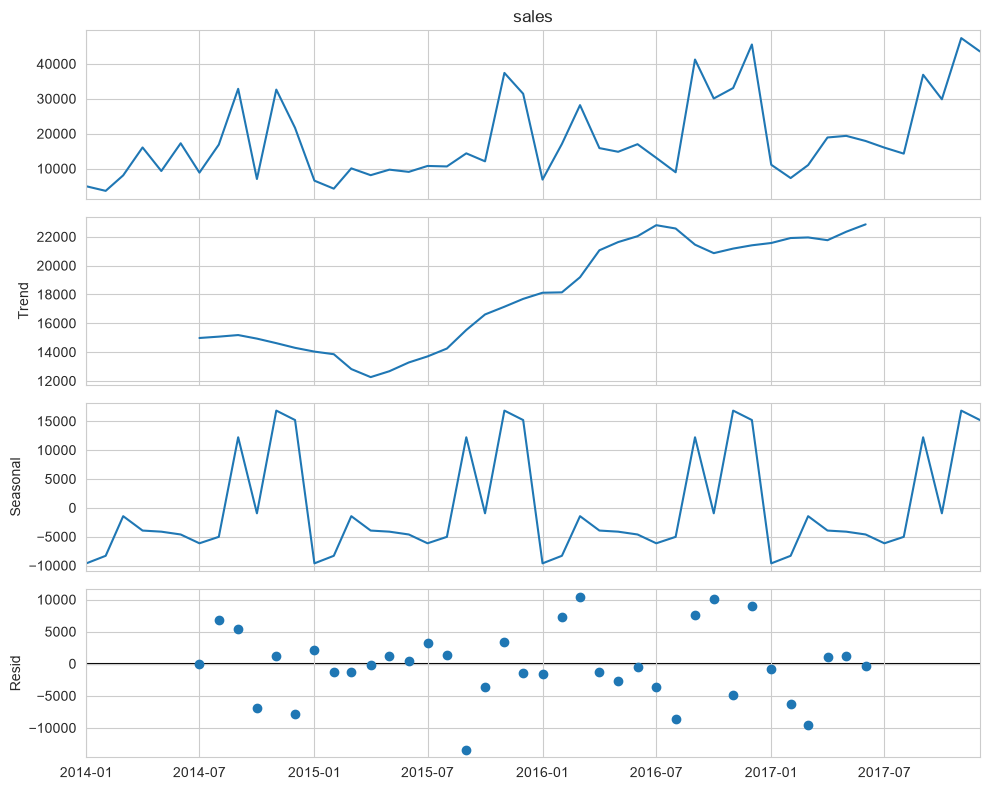

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=12 assumes monthly data with yearly seasonality; adjust if your date range is shorter
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()


### 2.3 Simple moving-average forecast
A 3-month moving average as a naive forecast baseline for next month's sales.


Naive 3-month moving-average forecast for next month: 40233.00


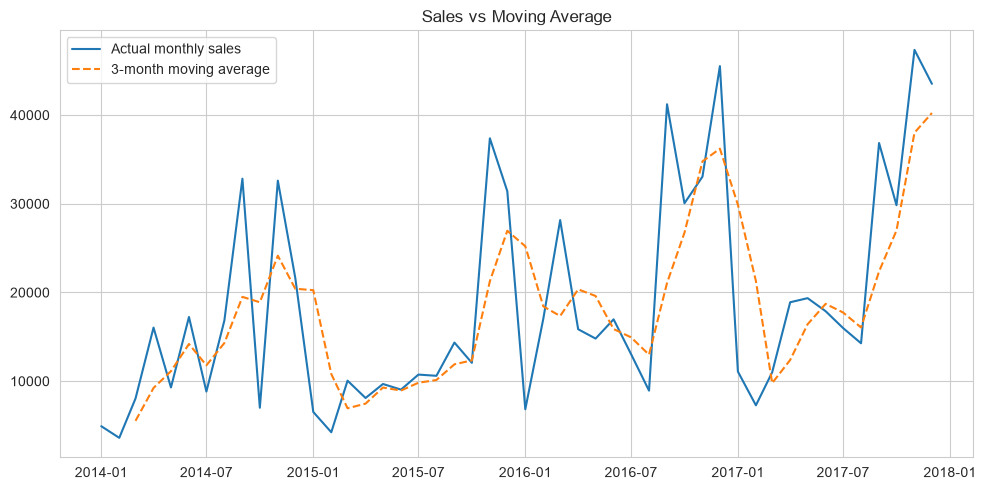

In [8]:
window = 3
moving_avg = monthly_sales.rolling(window=window).mean()

next_month_forecast = moving_avg.iloc[-1]
print(f"Naive {window}-month moving-average forecast for next month: {next_month_forecast:.2f}")

plt.plot(monthly_sales, label="Actual monthly sales")
plt.plot(moving_avg, label=f"{window}-month moving average", linestyle="--")
plt.legend()
plt.title("Sales vs Moving Average")
plt.tight_layout()
plt.show()


## 3. Customer Segmentation — Clustering (Day 23–24)

Build RFM-style features per customer (Recency, Frequency, Monetary, average Profit),
then cluster with K-Means.

### 3.1 Build customer-level features


In [9]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

customer_df = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_date", "count"),
    monetary=("sales", "sum"),
    avg_profit=("profit", "mean"),
).reset_index()

customer_df.head()


,customer_id,recency,frequency,monetary,avg_profit
0,AA-10315,649.0,5,5563.560,-32.989318
1,AA-10375,1.0,9,1056.390,18.492160
2,AA-10480,1318.0,1,1790.512,36.318950
3,AA-10645,37.0,12,5086.935,47.655739
4,AB-10015,397.0,5,886.156,21.557750


### 3.2 Scale features


In [16]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["recency", "frequency", "monetary", "avg_profit"]

print(customer_df[feature_cols].isnull().sum())
# Drop rows with missing values in any of the clustering features
customer_df_clean = customer_df.dropna(subset=feature_cols).reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_clean[feature_cols])

recency       55
frequency      0
monetary       0
avg_profit     0
dtype: int64


### 3.3 Elbow method to choose K


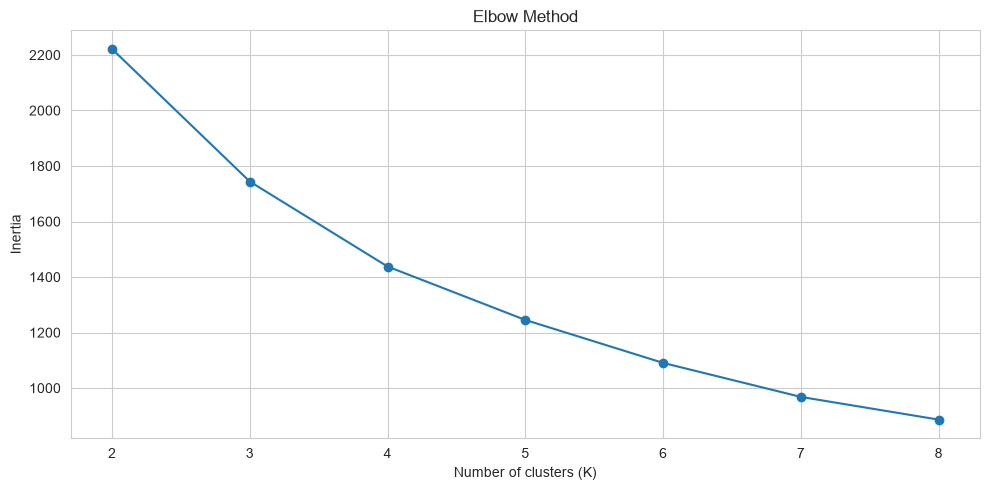

In [17]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

### 3.4 Fit K-Means with chosen K
Pick the K where the elbow bends (commonly 3–5 for RFM segmentation). Update `OPTIMAL_K` below.


In [19]:
optimal_k = 4  # update based on your elbow chart
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df_clean["cluster"] = kmeans.fit_predict(X_scaled)

### 3.5 Visualize clusters with PCA (2D)


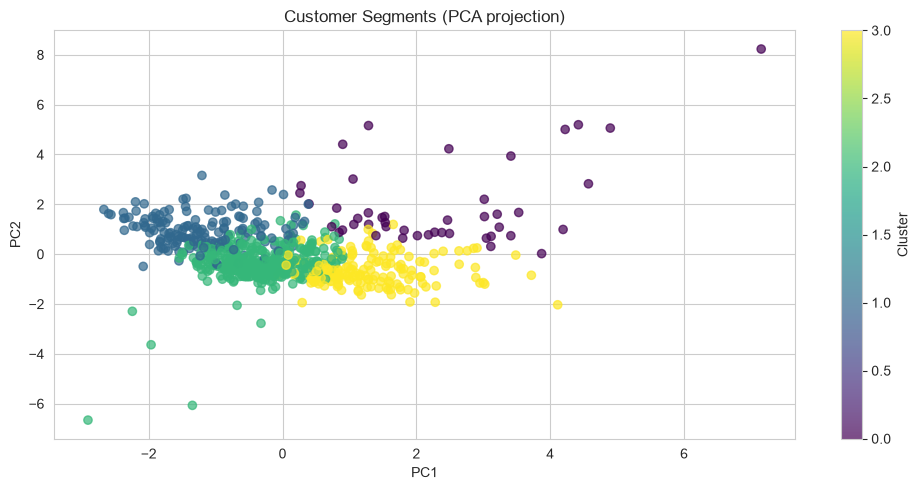

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.scatter(pcs[:, 0], pcs[:, 1], c=customer_df_clean["cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA projection)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


### 3.6 Profile each segment


In [22]:
profile = customer_df_clean.groupby("cluster")[feature_cols].mean().round(2)
display(profile)


,recency,frequency,monetary,avg_profit
cluster,,,,
0,323.49,6.09,9763.65,170.67
1,851.13,3.14,2072.87,20.95
2,166.06,3.99,2089.29,11.62
3,141.66,10.67,4013.39,25.90


**Segment recommendations** :

- **Cluster 0 — High-Value / VIP Customers** (monetary: 9,763.65, avg_profit: 170.67, recency: 323.49)
  Highest spend and by far the highest average profit per order, despite not being the most recent
  or frequent buyers. These are your most valuable customers by revenue and profitability — 
  prioritize retention perks, loyalty rewards, and early access to new products to keep them engaged.

- **Cluster 1 — Lapsed / At-Risk Customers** (recency: 851.13, frequency: 3.14, monetary: 2072.87)
  Haven't purchased in over 2 years on average (851 days), with the lowest purchase frequency and
  spend. This is a clear churn-risk segment — target with win-back campaigns, reactivation discounts,
  or personalized outreach before they're lost entirely.

- **Cluster 2 — Low-Value / Low-Engagement Customers** (monetary: 2,089.29, avg_profit: 11.62, frequency: 3.99)
  Moderate recency but the lowest average profit per order of any segment, with low purchase
  frequency. These customers may be highly price-sensitive or purchasing low-margin items — 
  consider upsell/cross-sell bundles to increase order value and profitability.

- **Cluster 3 — Active Frequent Buyers** (recency: 141.66, frequency: 10.67, monetary: 4013.39)
  Most recent purchasers with by far the highest purchase frequency, and solid monetary value.
  These are your engaged, habitual customers — good candidates for loyalty programs, subscription-style
  offers, or bundle deals that reward frequent purchasing behavior.

## 4. Basic Predictive Model (Day 25–26)

**Target:** predict `profit` (regression) from order-level features. Swap in a classification
target (e.g., a churn flag) instead if your dataset has one.

### 4.1 Prepare features and target


In [23]:
model_source = df[["sales", "quantity", "discount", "category", "sub_category",
                    "region", "segment", "profit"]].copy()

model_df = pd.get_dummies(
    model_source,
    columns=["category", "sub_category", "region", "segment"],
    drop_first=True,
)

X = model_df.drop(columns=["profit"])
y = model_df["profit"]


### 4.2 Train/test split (80/20)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 4.3 Fit Linear Regression


In [25]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)


### 4.4 Evaluate the model


In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:  {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


R^2:  -0.6440
MAE:  67.7047
RMSE: 282.3307


### 4.5 Top 3 most important features


In [27]:
coefficients = pd.Series(lr_model.coef_, index=X.columns)
top_features = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(3)

print("Top 3 features by absolute coefficient magnitude:")
print(top_features)


Top 3 features by absolute coefficient magnitude:
sub_category_Copiers     271.805318
discount                -237.025675
sub_category_Machines   -192.064441
dtype: float64


## Deliverables checklist
- [ ] Notebook saved with all cells run top-to-bottom (no errors), outputs visible
- [ ] Findings written up in Section 1.5 and 3.6 with your actual numbers
- [ ] Pushed to GitHub: `notebooks/task4_advanced_analytics.ipynb`
- [ ] LinkedIn post:
  > "Task 4 complete at @ApexPlanet! Performed hypothesis testing, customer segmentation
  > (K clusters), and built a prediction model with R² of ___. #DataScience #MachineLearning"
